# 2. 信用卡客户违约预测

## 一、实验简介

本实验围绕 **Default of Credit Card Clients Dataset**（UCI Machine Learning Repository）展开，目标是训练支持向量机（SVM）模型，预测客户是否会在下个月违约。

本实验重点关注两个问题：

1. **线性核 vs. RBF 核**：不同核函数对分类效果的影响。
2. **特征缩放的重要性**：使用 `StandardScaler` 前后，SVM 的表现差异。

## 二、实验目标

- 理解 SVM 适用于二分类任务的原因。
- 掌握 `LinearSVC` 与 `SVC(kernel="rbf")` 的基本用法。
- 理解为什么 SVM 对特征尺度敏感，以及 `StandardScaler` 的作用。
- 学会使用准确率、精确率、召回率、F1、ROC-AUC 等指标评价模型。

## 三、实验要求

- 使用同一训练/测试划分，保证比较公平。
- 比较四种方案：
  - 线性核 + 未缩放
  - 线性核 + 标准化
  - RBF 核 + 未缩放
  - RBF 核 + 标准化
- 输出分类报告、混淆矩阵、ROC 曲线和指标对比图。

## 四、思考提示

1. 为什么不缩放时，SVM 往往表现较差？
2. 为什么 RBF 核对特征缩放更加敏感？
3. 如果违约样本较少，应重点关注哪些指标？


## 1. 数据集介绍

该数据集包含 30,000 条样本，描述信用卡客户的基本信息、账单历史、还款历史等特征。

- **输入特征**：额度、性别、教育程度、婚姻状况、年龄、近 6 个月的还款状态、账单金额、还款金额等。
- **目标变量**：`default payment next month`，其中 `1` 表示下个月违约，`0` 表示未违约。

由于 SVM 依赖样本之间的距离和间隔，特征尺度差异较大时会影响模型训练，因此标准化是本实验的关键步骤。

> 为了保证课堂运行速度，本 notebook 默认会从数据集中**分层抽样 1000 条样本**进行演示；如果你想做完整实验，可以把抽样参数改为 `None`。


In [1]:
from __future__ import annotations

import re
import warnings
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
	accuracy_score,
	classification_report,
	confusion_matrix,
	f1_score,
	precision_score,
	recall_score,
	roc_auc_score,
	RocCurveDisplay,
)
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore")

def configure_plot_fonts() -> None:
	"""配置 matplotlib 中文字体，避免 seaborn 主题覆盖字体设置。"""

	sns.set_theme(style="whitegrid")
	font_candidates = [
		"Microsoft YaHei",
		"SimHei",
		"Noto Sans CJK SC",
		"PingFang SC",
		"WenQuanYi Zen Hei",
	]
	available_fonts = {f.name for f in font_manager.fontManager.ttflist}
	selected_font = next((name for name in font_candidates if name in available_fonts), None)

	if selected_font is None:
		warnings.warn(
			"未检测到常见中文字体，图表中文可能显示为方块。"
			"建议安装 'Microsoft YaHei' 或 'Noto Sans CJK SC'。",
			UserWarning,
		)
		plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
	else:
		plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]

	plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()

DEFAULT_CREDIT_COLUMNS = [
	"LIMIT_BAL",
	"SEX",
	"EDUCATION",
	"MARRIAGE",
	"AGE",
	"PAY_0",
	"PAY_2",
	"PAY_3",
	"PAY_4",
	"PAY_5",
	"PAY_6",
	"BILL_AMT1",
	"BILL_AMT2",
	"BILL_AMT3",
	"BILL_AMT4",
	"BILL_AMT5",
	"BILL_AMT6",
	"PAY_AMT1",
	"PAY_AMT2",
	"PAY_AMT3",
	"PAY_AMT4",
	"PAY_AMT5",
	"PAY_AMT6",
]

DEFAULT_SAMPLE_SIZE = 1000


## 2. 数据获取与读取

本实验的数据获取方式说明如下：

- **数据集学术来源（provenance）**：UCI Machine Learning Repository。
- **本 notebook 的实际加载源（single source）**：OpenML `data_id=42477`。

也就是说，实验代码通过 OpenML API 拉取数据，但数据任务对应的是 UCI 公开的数据集条目。为了保证可复现性，本实验固定使用 `fetch_openml(data_id=42477, as_frame=True)` 这一条加载路径，不设置其他回退数据源。

参考页面：

- UCI 页面：<https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients>
- OpenML 页面：<https://www.openml.org/d/42477>


In [2]:
def load_credit_card_default_data(sample_size: int | None = DEFAULT_SAMPLE_SIZE, random_state: int = 42) -> tuple[pd.DataFrame, pd.Series]:
	"""从 OpenML 读取信用卡违约预测数据集。"""

	dataset = fetch_openml(data_id=42477, as_frame=True)
	X = dataset.data.copy()
	y = pd.Series(dataset.target)

	X = X.copy()
	X.columns = [str(c).strip() for c in X.columns]
	if len(X.columns) == 23 and all(re.fullmatch(r"x\d+", str(col).lower()) for col in X.columns):
		X.columns = DEFAULT_CREDIT_COLUMNS
	y = pd.to_numeric(pd.Series(y), errors="coerce").astype(int)
	y.name = "default_payment_next_month"

	if sample_size is not None:
		if sample_size <= 0:
			raise ValueError("sample_size 必须为正整数或 None")
		if sample_size < len(X):
			X, _, y, _ = train_test_split(
				X,
				y,
				train_size=sample_size,
				stratify=y,
				random_state=random_state,
			)
			X = X.reset_index(drop=True)
			y = y.reset_index(drop=True)

	return X, y


X, y = load_credit_card_default_data()
print("特征矩阵维度：", X.shape)
print("目标变量名称：", y.name)
print("\n目标分布：")
print(y.value_counts().rename(index={0: "未违约", 1: "违约"}))


特征矩阵维度： (1000, 23)
目标变量名称： default_payment_next_month

目标分布：
default_payment_next_month
未违约    779
违约     221
Name: count, dtype: int64


## 3. 数据概览与初步检查

我们先检查数据类型、缺失值情况和类别分布。

这个数据集是典型的**类别不平衡**任务：`违约=1` 往往明显少于 `未违约=0`。这会带来两个直接挑战：

1. 模型容易“偏向多数类”，即使几乎不识别违约客户，准确率也可能看起来不低。
2. 评估时需要更重视 `recall / F1 / ROC-AUC`，并在训练阶段考虑 `class_weight="balanced"` 或重采样等策略。

因此，本实验除了看总体分数，更强调看错分结构（混淆矩阵）和排序能力（ROC 曲线）。


In [3]:
display(X.head())
display(X.info())

missing_summary = X.isna().sum().sort_values(ascending=False)
print("缺失值统计（前 10 项）：")
print(missing_summary.head(10))

dup_count = X.duplicated().sum()
print(f"\n重复样本数：{dup_count}")

print("\n目标类别分布：")
print(y.value_counts().rename(index={0: "未违约", 1: "违约"}))


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,260000,2,2,1,40,0,0,0,0,0,...,133752,135053,133888,132486,4870,6307,5007,5015,4773,4770
1,80000,2,2,1,38,0,0,0,0,0,...,53897,54292,55430,57011,2125,2000,2000,2010,2500,1336
2,50000,2,5,2,36,0,0,0,0,0,...,20361,17527,17318,17738,2058,1265,5000,700,700,800
3,220000,1,1,2,27,0,0,-1,-1,-1,...,1744,55164,49967,7839,8,2178,55200,50148,10107,0
4,140000,1,1,2,35,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  1000 non-null   int64
 1   SEX        1000 non-null   int64
 2   EDUCATION  1000 non-null   int64
 3   MARRIAGE   1000 non-null   int64
 4   AGE        1000 non-null   int64
 5   PAY_0      1000 non-null   int64
 6   PAY_2      1000 non-null   int64
 7   PAY_3      1000 non-null   int64
 8   PAY_4      1000 non-null   int64
 9   PAY_5      1000 non-null   int64
 10  PAY_6      1000 non-null   int64
 11  BILL_AMT1  1000 non-null   int64
 12  BILL_AMT2  1000 non-null   int64
 13  BILL_AMT3  1000 non-null   int64
 14  BILL_AMT4  1000 non-null   int64
 15  BILL_AMT5  1000 non-null   int64
 16  BILL_AMT6  1000 non-null   int64
 17  PAY_AMT1   1000 non-null   int64
 18  PAY_AMT2   1000 non-null   int64
 19  PAY_AMT3   1000 non-null   int64
 20  PAY_AMT4   1000 non-null   int64
 21  PAY_AMT5   1000 non-null  

None

缺失值统计（前 10 项）：
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
dtype: int64

重复样本数：0

目标类别分布：
default_payment_next_month
未违约    779
违约     221
Name: count, dtype: int64


## 4. 数据预处理

在这个数据集中，`SEX`、`EDUCATION`、`MARRIAGE` 虽然以数字形式存储，但本质上属于类别编码。

为了减少异常编码对模型的干扰，我们做两个常见处理：

- 将 `EDUCATION` 中的异常值（0、5、6）合并为 `4`（其他类别）
- 将 `MARRIAGE` 中的异常值 `0` 合并为 `3`（其他类别）

注意：本实验为了突出“**SVM + 标准化**”的效果，仍然保留这些字段的数值编码形式，不额外做 One-Hot 编码。

这里补充说明几种常见编码方法：

- **标签/序号编码（当前做法）**：直接用整数表示类别，优点是实现简单、维度不膨胀；缺点是模型可能误以为类别之间有大小关系。
- **One-Hot 编码**：把每个类别展开为 0/1 列，能避免伪序关系；缺点是维度增加，训练更慢，且在小样本下可能更稀疏。
- **目标编码/频数编码**：在工业场景常见，但需要更严格的交叉验证防止泄漏，不适合作为本章入门主线。

本实验保留数值编码，目的是让你更专注比较“核函数 + 标准化”的核心差异；在章节思考题中会引导你尝试 One-Hot 做拓展对比。


In [4]:
X = X.copy()

if "EDUCATION" in X.columns:
	X["EDUCATION"] = X["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

if "MARRIAGE" in X.columns:
	X["MARRIAGE"] = X["MARRIAGE"].replace({0: 3})

for col in X.columns:
	X[col] = pd.to_numeric(X[col], errors="coerce")

valid_mask = X.notna().all(axis=1)
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

print("预处理后维度：", X.shape)
print("处理后目标分布：")
print(y.value_counts().rename(index={0: "未违约", 1: "违约"}))


预处理后维度： (1000, 23)
处理后目标分布：
default_payment_next_month
未违约    779
违约     221
Name: count, dtype: int64


## 5. 训练集 / 测试集划分

为了保证对比公平，所有模型都使用相同的数据划分。


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y,
)

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)


训练集大小： (800, 23)
测试集大小： (200, 23)


## 6. 模型构建

本节构建并比较四个 SVM 方案，在相同训练/测试划分下评估“核函数类型”和“是否标准化”对结果的影响。


In [6]:
def build_svm_pipeline(kernel: str, use_scaler: bool, C: float = 1.0, gamma: str = "scale") -> Pipeline:
	steps = []
	if use_scaler:
		steps.append(("scaler", StandardScaler()))
	if kernel == "linear":
		steps.append(("svm", LinearSVC(C=C, class_weight="balanced", dual="auto", max_iter=5000)))
	else:
		steps.append(("svm", SVC(kernel=kernel, C=C, gamma=gamma, class_weight="balanced")))
	return Pipeline(steps)


def evaluate_model(model: Pipeline, X_eval: pd.DataFrame, y_eval: pd.Series) -> dict:
	y_pred = model.predict(X_eval)
	scores = model.decision_function(X_eval)
	return {
		"accuracy": accuracy_score(y_eval, y_pred),
		"precision": precision_score(y_eval, y_pred, zero_division=0),
		"recall": recall_score(y_eval, y_pred, zero_division=0),
		"f1": f1_score(y_eval, y_pred, zero_division=0),
		"roc_auc": roc_auc_score(y_eval, scores),
		"confusion_matrix": confusion_matrix(y_eval, y_pred),
		"y_pred": y_pred,
		"scores": scores,
	}


### 6.1 定义四组对比实验

我们固定训练/测试集划分，只改变两个因素：

1. 核函数（`linear` vs `rbf`）
2. 是否标准化（`use_scaler=True/False`）

`Pipeline` 的作用是把“预处理 + 模型”封装为一个整体对象，保证训练和预测阶段使用一致的数据变换流程：

- 未标准化方案：`Pipeline([("svm", ...)])`
- 标准化方案：`Pipeline([("scaler", StandardScaler()), ("svm", ...)])`

这种写法可以避免数据泄漏（只在训练集拟合 scaler），并且让不同实验方案的代码结构完全一致，便于公平比较。


In [7]:
experiments = {
	"Linear-SVM（未缩放）": build_svm_pipeline(kernel="linear", use_scaler=False),
	"Linear-SVM（标准化）": build_svm_pipeline(kernel="linear", use_scaler=True),
	"RBF-SVM（未缩放）": build_svm_pipeline(kernel="rbf", use_scaler=False),
	"RBF-SVM（标准化）": build_svm_pipeline(kernel="rbf", use_scaler=True),
}


### 6.2 逐个训练模型并记录耗时

这里同时记录两类信息：

- **训练耗时**：帮助理解不同方案的计算成本；
- **测试集指标**：用于后续统一比较分类性能。


In [8]:
fitted_models: dict[str, Pipeline] = {}
results: list[dict] = []
fit_time_rows: list[dict[str, float | str]] = []
section6_start = perf_counter()

for name, model in experiments.items():
	print(f"正在训练：{name}")
	fit_start = perf_counter()
	model.fit(X_train, y_train)
	fit_seconds = perf_counter() - fit_start
	print(f"{name} 训练耗时：{fit_seconds:.2f}s")
	fitted_models[name] = model
	metrics = evaluate_model(model, X_test, y_test)
	metrics["model"] = name
	results.append(metrics)
	fit_time_rows.append({"model": name, "fit_seconds": fit_seconds})

section6_seconds = perf_counter() - section6_start
print(f"Section 6 总训练耗时：{section6_seconds:.2f}s")


正在训练：Linear-SVM（未缩放）
Linear-SVM（未缩放） 训练耗时：0.01s
正在训练：Linear-SVM（标准化）
Linear-SVM（标准化） 训练耗时：0.00s
正在训练：RBF-SVM（未缩放）
RBF-SVM（未缩放） 训练耗时：0.01s
正在训练：RBF-SVM（标准化）
RBF-SVM（标准化） 训练耗时：0.01s
Section 6 总训练耗时：0.07s


### 6.3 汇总指标表

`results_df` 用于对比核心分类指标，`results_with_time_df` 在此基础上补充训练耗时。

各指标含义：

- `accuracy`：总体预测正确比例；在不平衡数据上可能偏乐观。
- `precision`：预测为“违约”的样本中，真正违约的比例。
- `recall`：真实“违约”样本中，被成功识别出来的比例。
- `f1`：`precision` 与 `recall` 的调和平均，适合不平衡任务的综合比较。
- `roc_auc`：模型对正负样本整体排序能力，越接近 1 越好。
- `fit_seconds`：训练时间，用于比较效果与计算成本。

在信贷违约场景中，通常优先关注 `recall`、`f1` 和 `roc_auc`，再结合 `precision` 与训练成本做最终方案选择。


In [9]:
results_df = pd.DataFrame(results).set_index("model")
results_df = results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].sort_values("f1", ascending=False)
fit_time_df = pd.DataFrame(fit_time_rows).set_index("model")
results_with_time_df = results_df.join(fit_time_df)
results_with_time_df


,accuracy,precision,recall,f1,roc_auc,fit_seconds
model,,,,,,
Linear-SVM（未缩放）,0.620,0.322222,0.659091,0.432836,0.681090,0.009935
RBF-SVM（标准化）,0.695,0.365079,0.522727,0.429907,0.716200,0.010580
Linear-SVM（标准化）,0.615,0.314607,0.636364,0.421053,0.683712,0.002584
RBF-SVM（未缩放）,0.560,0.260870,0.545455,0.352941,0.584645,0.009490


## 7. 结果分析：分类报告

先查看表现最好的模型在测试集上的详细分类报告。

阅读 `classification_report` 时建议按下面顺序：

1. 先看 `违约(1)` 的 `recall`：漏掉违约客户的代价通常更高。
2. 再看 `precision`：过低会导致大量“误报违约”，影响业务可用性。
3. 结合 `f1-score`：在 precision/recall 间做平衡判断。
4. 最后再看 `accuracy`：它对不平衡数据不够敏感，不能单独作为结论。


In [10]:
best_model_name = results_df["roc_auc"].idxmax()
best_model = fitted_models[best_model_name]

print("ROC-AUC 最优模型：", best_model_name)
print(classification_report(y_test, best_model.predict(X_test), digits=4))


ROC-AUC 最优模型： RBF-SVM（标准化）
              precision    recall  f1-score   support

           0     0.8467    0.7436    0.7918       156
           1     0.3651    0.5227    0.4299        44

    accuracy                         0.6950       200
   macro avg     0.6059    0.6332    0.6109       200
weighted avg     0.7408    0.6950    0.7122       200



## 8. 指标对比可视化

下面把四种方案的核心指标可视化，便于观察标准化和核函数的影响。

看图时可以重点回答三个问题：

- 同一核函数下，标准化是否让 `f1` 和 `roc_auc` 同时上升？
- 同样是否标准化时，`linear` 与 `rbf` 谁在召回率上更稳？
- 若某模型准确率高但召回率低，是否只是“偏向预测未违约”？


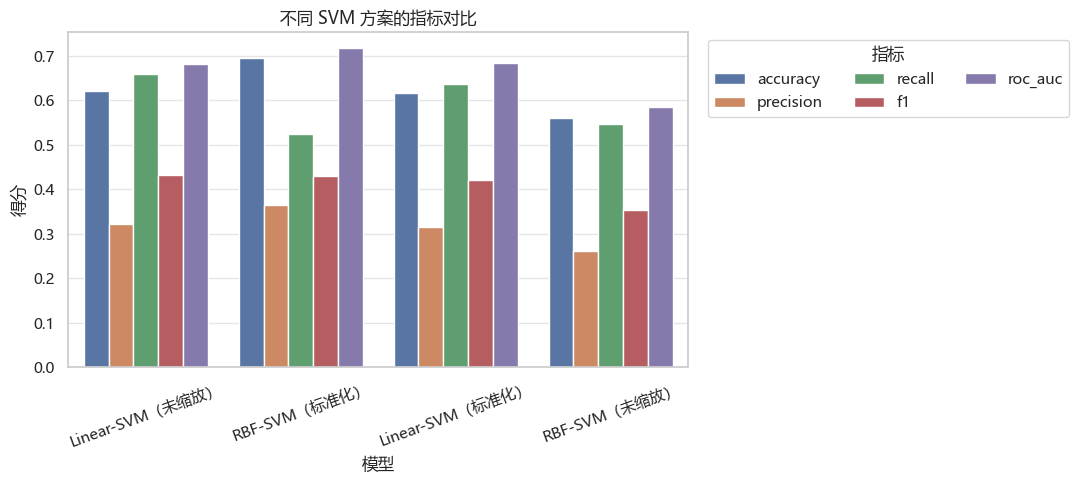

In [11]:
plot_df = results_df.reset_index().melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=plot_df, x="model", y="value", hue="metric")
ax.set_title("不同 SVM 方案的指标对比")
ax.set_xlabel("模型")
ax.set_ylabel("得分")
plt.xticks(rotation=20)
plt.legend(title="指标", ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. 混淆矩阵对比

混淆矩阵可以帮助我们观察：模型究竟更容易把“违约”错判为“未违约”，还是相反。

建议重点观察右下角（真正例）和左下角（假负例）：

- 左下角（真实违约但预测未违约）越大，说明漏判风险越高；
- 右上角（真实未违约但预测违约）越大，说明误报越多；
- 在风控场景中，通常会优先控制漏判，再根据业务成本调节阈值。


In [12]:
for name, model in fitted_models.items():
	print(f"\n{name} 的混淆矩阵：")
	cm = confusion_matrix(y_test, model.predict(X_test))
	cm_df = pd.DataFrame(cm, index=["真实：未违约", "真实：违约"], columns=["预测：未违约", "预测：违约"])
	print(cm_df.to_string())



Linear-SVM（未缩放） 的混淆矩阵：
        预测：未违约  预测：违约
真实：未违约      95     61
真实：违约       15     29

Linear-SVM（标准化） 的混淆矩阵：
        预测：未违约  预测：违约
真实：未违约      95     61
真实：违约       16     28

RBF-SVM（未缩放） 的混淆矩阵：
        预测：未违约  预测：违约
真实：未违约      88     68
真实：违约       20     24

RBF-SVM（标准化） 的混淆矩阵：
        预测：未违约  预测：违约
真实：未违约     116     40
真实：违约       21     23


## 10. ROC 曲线对比

ROC 曲线与 ROC-AUC 反映模型对正负样本的整体区分能力。对于不平衡分类任务，这个指标通常比单纯准确率更有参考价值。

如何解读：

- 曲线越靠左上，表示在较低假阳性率下就能获得较高真阳性率；
- AUC 越接近 1，模型整体排序能力越强；
- 若两条曲线有交叉，说明不同阈值区间各有优劣，需要结合业务偏好（例如更重召回或更重精确）来选模型。


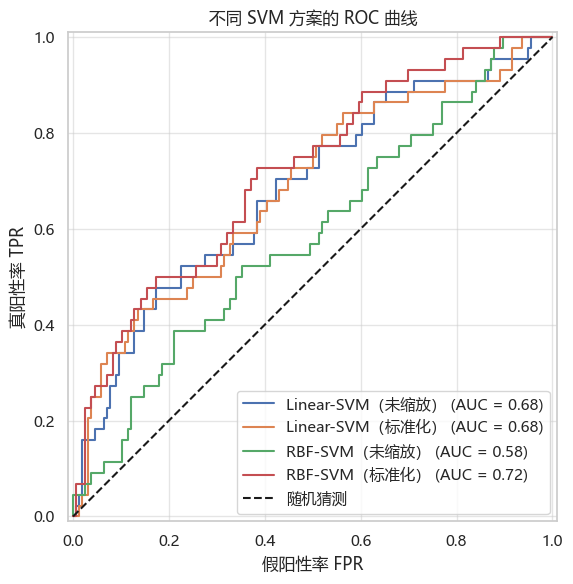

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in fitted_models.items():
	scores = model.decision_function(X_test)
	RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="随机猜测")
ax.set_title("不同 SVM 方案的 ROC 曲线")
ax.set_xlabel("假阳性率 FPR")
ax.set_ylabel("真阳性率 TPR")
ax.legend()
plt.tight_layout()
plt.show()


## 11. 决策边界可视化（PCA 2D 近似）

由于原始数据有 23 个特征，真实决策边界无法直接画在二维平面上。下面先对特征做标准化，再压缩到两个主成分，仅用于直观观察线性核和 RBF 核的边界形状差异。

这里的图是“教学近似图”，你可以这样理解：

1. **决策边界** 是模型把样本空间分成“预测未违约/预测违约”两侧的分隔线（高维里是超平面或复杂曲面）。
2. **LinearSVC** 往往形成更接近直线的分界；**RBF-SVC** 可以形成弯曲边界，表达能力更强。
3. 由于 PCA 会丢失一部分信息，这个图不能当作严格证据，只用于帮助你建立对核函数差异的直观认识。

### 11.1 可视化辅助函数


In [14]:
def prepare_pca_boundary_data(
	X_train: pd.DataFrame,
	X_test: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
	"""将原始特征标准化后压缩到 2D，便于可视化决策边界。"""

	scaler = StandardScaler()
	pca = PCA(n_components=2, random_state=42)
	X_train_scaled = scaler.fit_transform(X_train)
	X_test_scaled = scaler.transform(X_test)
	X_train_2d = pca.fit_transform(X_train_scaled)
	X_test_2d = pca.transform(X_test_scaled)
	return X_train_2d, X_test_2d


def plot_decision_boundary_2d(ax, model: Pipeline, X_2d: np.ndarray, y_2d: pd.Series, title: str) -> None:
	"""绘制二维决策边界，仅用于教学演示。"""

	x_min, x_max = X_2d[:, 0].min() - 1.0, X_2d[:, 0].max() + 1.0
	y_min, y_max = X_2d[:, 1].min() - 1.0, X_2d[:, 1].max() + 1.0
	xx, yy = np.meshgrid(
		np.linspace(x_min, x_max, 300),
		np.linspace(y_min, y_max, 300),
	)
	grid = np.c_[xx.ravel(), yy.ravel()]
	zz = model.predict(grid).reshape(xx.shape)

	ax.contourf(xx, yy, zz, alpha=0.22, cmap="coolwarm", levels=[-0.5, 0.5, 1.5])
	ax.scatter(
		X_2d[y_2d == 0, 0],
		X_2d[y_2d == 0, 1],
		c="#4C72B0",
		s=22,
		alpha=0.8,
		label="未违约",
		edgecolors="white",
		linewidths=0.3,
	)
	ax.scatter(
		X_2d[y_2d == 1, 0],
		X_2d[y_2d == 1, 1],
		c="#DD8452",
		s=22,
		alpha=0.8,
		label="违约",
		edgecolors="white",
		linewidths=0.3,
	)
	ax.set_title(title)
	ax.set_xlabel("PC1")
	ax.set_ylabel("PC2")
	ax.legend(loc="best")


### 11.2 绘制二维近似决策边界


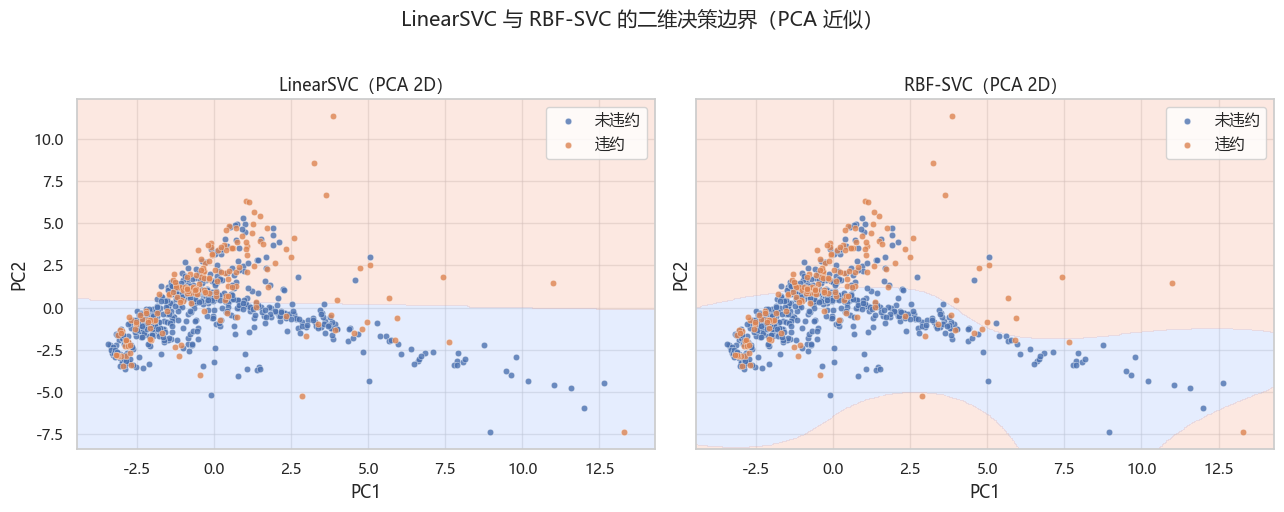

In [15]:
X_train_2d, X_test_2d = prepare_pca_boundary_data(X_train, X_test)
boundary_models = {
	"LinearSVC（PCA 2D）": build_svm_pipeline(kernel="linear", use_scaler=False),
	"RBF-SVC（PCA 2D）": build_svm_pipeline(kernel="rbf", use_scaler=False),
}

for model in boundary_models.values():
	model.fit(X_train_2d, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, boundary_models.items()):
	plot_decision_boundary_2d(ax, model, X_train_2d, y_train, name)

fig.suptitle("LinearSVC 与 RBF-SVC 的二维决策边界（PCA 近似）", y=1.02)
plt.tight_layout()
plt.show()


## 12. 实验结论

请结合你运行后的结果，完成下面的总结：

1. **标准化是否带来了明显提升？**
   - 如果标准化后 F1 / ROC-AUC 提升，说明 SVM 对特征尺度非常敏感。
   - 若提升不明显，也要结合线性核与 RBF 核的差异进行分析。

2. **线性核与 RBF 核的区别是什么？**
   - 线性核更简单，训练更快，适合近似线性可分的数据。
   - RBF 核可以捕捉非线性关系，但对参数和特征缩放更敏感。

3. **为什么不建议只看准确率？**
   - 违约样本通常占少数，模型即使把大多数样本都判成“未违约”，准确率也可能很高。
   - 因此应重点关注 **召回率、F1、ROC-AUC**。

### 教学结论（参考）

在这类信贷风险预测任务中，**先做标准化，再训练 SVM** 几乎是默认做法。特征尺度统一后，模型更容易找到合理的间隔；对于 RBF 核来说，距离计算也更稳定，通常能带来更好的分类效果。


## 13. 课堂思考题

1. 如果你把 `class_weight="balanced"` 去掉，结果会如何变化？
2. 如果把 `C` 增大或减小，模型的偏差和方差会怎样变化？
3. 你能否尝试网格搜索 `C` 和 `gamma`，进一步优化 RBF-SVM？
4. 如果对 `SEX`、`EDUCATION`、`MARRIAGE` 做 One-Hot 编码，结果是否会更好？为什么？

---

### 建议运行顺序

1. 先运行所有代码单元，确保数据可以成功下载。
2. 再观察 `results_df`、混淆矩阵和 ROC 曲线。
3. 最后根据结果撰写实验报告。
